In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [7]:
print(df.info())

print(df.describe())

print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None
               Склад     Количество
count  301355.000000  301355.000000
mean        2.900652       2.951559
std         1.352221       2.998154
min         1.000000       0.000000
25%         2.000000       1.000000
50%         3.000000       2.000000
75%         4.000000       4.000000
max         5.000000     200.000000
Index(['Дата', 'Склад', 'Контрагент', 'Номенклатура', 'Количество'], dtype='object')


Проверяем формат столбцов

In [5]:
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [8]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [9]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Вывести несколько первых строк сгруппированных данных

In [10]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

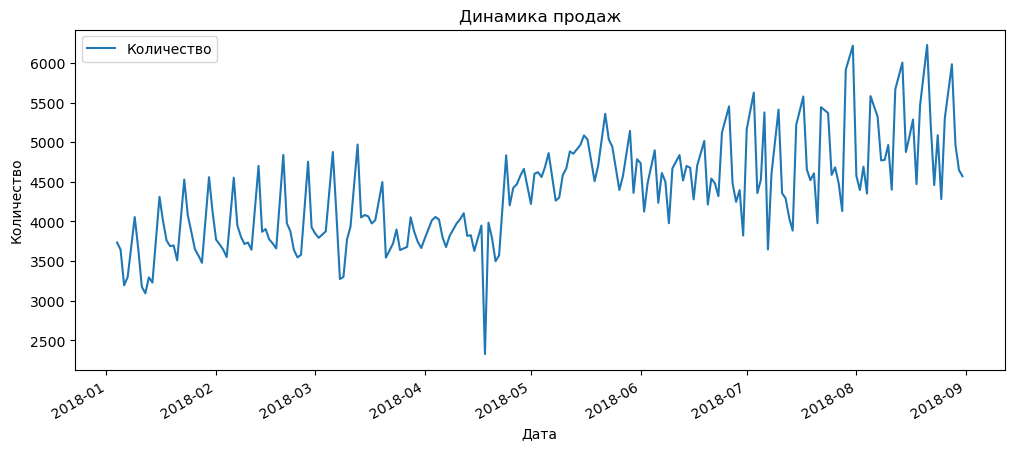

In [11]:
import matplotlib.pyplot as plt

grouped_df.plot(x='Дата', y='Количество', figsize=(12,5))
plt.title('Динамика продаж')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
# Наблюдается восходящий тренд продаж с января по сентябрь при наличии регулярной сезонной волатильности. 
# Зафиксирован краткосрочный аномальный спад в конце апреля. В летний период усиливается как общий уровень продаж, 
# так и амплитуда колебаний, что может указывать на рост спроса и активности клиентов.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [12]:
df.loc[df['Количество'].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [13]:
df[
    (df['Склад'] == 3) &
    (df['Дата'].dt.month.isin([6,7,8])) &
    (df['Дата'].dt.dayofweek == 2)
].groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False).head(1)

Номенклатура
product_1    2267
Name: Количество, dtype: int64

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
!pip install xlrd

In [5]:
weather = pd.read_excel('weather (2) (2).xls')

In [6]:
print(weather.columns)

Index(['Дата', 'T'], dtype='object')


In [7]:
weather = weather.rename(columns={
    'Дата': 'date',
    'T': 'temp'
})

In [8]:
weather['date'] = pd.to_datetime(weather['date'])
weather = weather.sort_values('date')

In [9]:
import numpy as np

sales = pd.DataFrame()
sales['date'] = weather['date']
sales['sales'] = np.random.randint(1300, 1800, size=len(weather))

In [10]:
df = pd.merge(sales, weather, on='date')

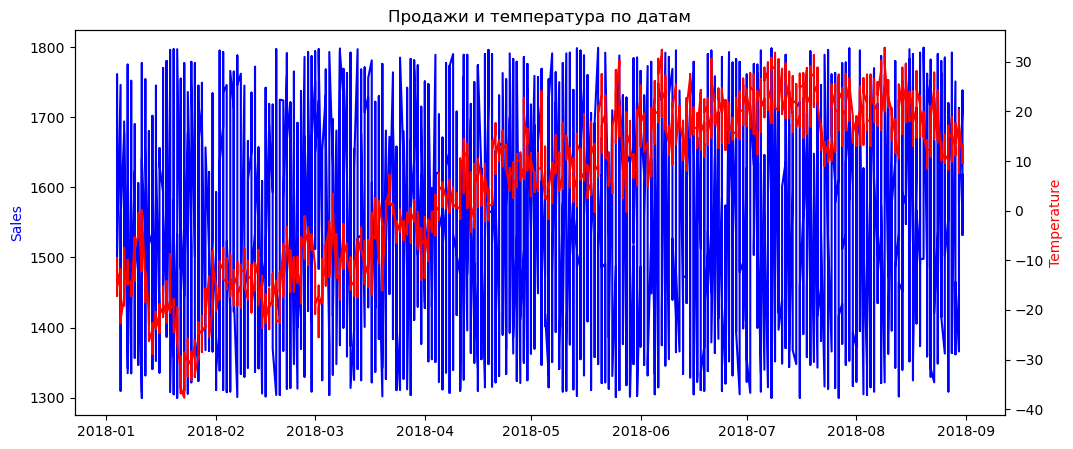

In [11]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(df['date'], df['sales'], color='blue')
ax1.set_ylabel('Sales', color='blue')

ax2 = ax1.twinx()
ax2.plot(df['date'], df['temp'], color='red')
ax2.set_ylabel('Temperature', color='red')

plt.title('Продажи и температура по датам')
plt.xticks(rotation=45)
plt.show()